In [ ]:
# Cell 1 — Install compatible pytorch-lightning (NOT 1.5.6)
!pip install pytorch-lightning==1.9.5 torchvision matplotlib PyYAML omegaconf -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 13.6 MB/s eta 0:00:00a 0:00:01


In [ ]:
# Cell 2 — Clone and enter repo
!git clone https://github.com/AntixK/PyTorch-VAE /kaggle/working/PyTorch-VAE
import os
os.chdir('/kaggle/working/PyTorch-VAE')
!ls

Cloning into '/kaggle/working/PyTorch-VAE'...
remote: Enumerating objects: 862, done.
remote: Counting objects: 100% (447/447), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 862 (delta 415), reused 403 (delta 403), pack-reused 415 (from 1)
Receiving objects: 100% (862/862), 46.46 MiB | 54.44 MiB/s, done.
Resolving deltas: 100% (621/621), done.
assets	 dataset.py	LICENSE.md  README.md	      run.py  utils.py
configs  experiment.py	models	    requirements.txt  tests


In [ ]:
# Cell 3 — Patch experiment.py to fix Lightning 1.9 compatibility issues
patch = '''import os
import math
import torch
from torch import optim
from models import BaseVAE
from models.types_ import *
from utils import data_loader
import pytorch_lightning as pl
from torchvision import transforms
import torchvision.utils as vutils
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader


class VAEXperiment(pl.LightningModule):

    def __init__(self, vae_model: BaseVAE, params: dict) -> None:
        super(VAEXperiment, self).__init__()
        self.model = vae_model
        self.params = params
        self.curr_device = None
        self.hold_graph = False
        try:
            self.hold_graph = self.params['retain_first_backpass']
        except:
            pass

    def forward(self, input: Tensor, **kwargs) -> Tensor:
        return self.model(input, **kwargs)

    def training_step(self, batch, batch_idx):
        real_img, labels = batch
        self.curr_device = real_img.device
        results = self.forward(real_img, labels=labels)
        train_loss = self.model.loss_function(*results,
                                              M_N=self.params['kld_weight'],
                                              batch_idx=batch_idx)
        self.log_dict({key: val.item() for key, val in train_loss.items()}, sync_dist=True)
        return train_loss['loss']

    def validation_step(self, batch, batch_idx):
        real_img, labels = batch
        self.curr_device = real_img.device
        results = self.forward(real_img, labels=labels)
        val_loss = self.model.loss_function(*results,
                                            M_N=1.0,
                                            batch_idx=batch_idx)
        self.log_dict({f"val_{key}": val.item() for key, val in val_loss.items()}, sync_dist=True)

    def on_validation_end(self) -> None:
        self.sample_images()

    def sample_images(self):
        test_input, test_label = next(iter(self.trainer.datamodule.test_dataloader()))
        test_input = test_input.to(self.curr_device)
        test_label = test_label.to(self.curr_device)
        recons = self.model.generate(test_input, labels=test_label)
        os.makedirs(f"{self.logger.log_dir}/Reconstructions/", exist_ok=True)
        vutils.save_image(recons.data,
                          os.path.join(self.logger.log_dir, "Reconstructions",
                                       f"recons_{self.logger.name}_Epoch_{self.current_epoch}.png"),
                          normalize=True, nrow=12)
        try:
            samples = self.model.sample(144, self.curr_device, labels=test_label)
            os.makedirs(f"{self.logger.log_dir}/Samples/", exist_ok=True)
            vutils.save_image(samples.cpu().data,
                              os.path.join(self.logger.log_dir, "Samples",
                                           f"{self.logger.name}_Epoch_{self.current_epoch}.png"),
                              normalize=True, nrow=12)
        except Warning:
            pass

    def configure_optimizers(self):
        optimizer = optim.Adam(self.model.parameters(),
                               lr=self.params['LR'],
                               weight_decay=self.params.get('weight_decay', 0))
        scheduler = optim.lr_scheduler.ExponentialLR(
            optimizer, gamma=self.params.get('scheduler_gamma', 0.95))
        return [optimizer], [scheduler]
'''

with open('/kaggle/working/PyTorch-VAE/experiment.py', 'w') as f:
    f.write(patch)

print("experiment.py patched ✅")

experiment.py patched ✅


In [ ]:
# Cell 4 — Patch run.py
run_patch = '''import os
import yaml
import argparse
import numpy as np
import torch
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.plugins import DDPPlugin

from models import vae_models
from experiment import VAEXperiment
from dataset import VAEDataset

parser = argparse.ArgumentParser(description='PyTorch-VAE Runner')
parser.add_argument('--config', '-c', dest="filename", metavar='FILE',
                    help='path to config file', default='configs/vae.yaml')
args = parser.parse_args()

with open(args.filename, 'r') as f:
    config = yaml.safe_load(f)

tb_logger = TensorBoardLogger(
    save_dir=config['logging_params']['save_dir'],
    name=config['logging_params']['name']
)

model = vae_models[config['model_params']['name']](**config['model_params'])
experiment = VAEXperiment(model, config['exp_params'])

data = VAEDataset(**config["data_params"], pin_memory=len(config['trainer_params'].get('gpus', [])) != 0)
data.setup()

runner = Trainer(
    logger=tb_logger,
    callbacks=[
        LearningRateMonitor(),
        ModelCheckpoint(
            save_top_k=2,
            dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
            monitor="val_loss",
            save_last=True
        ),
    ],
    **config['trainer_params']
)

print(f"Training {config['model_params']['name']} ======= Starting Training =======")
runner.fit(experiment, datamodule=data)
'''

with open('/kaggle/working/PyTorch-VAE/run.py', 'w') as f:
    f.write(run_patch)

print("run.py patched ✅")

run.py patched ✅


In [ ]:
# Cell 5 — Write config yaml
import yaml, os

config = {
    'model_params': {
        'name': 'VanillaVAE',
        'in_channels': 3,
        'latent_dim': 128
    },
    'data_params': {
        'data_path': '/kaggle/input/datasets/jessicali9530/celeba-dataset/',
        'train_batch_size': 64,
        'val_batch_size': 64,
        'patch_size': 64,
        'num_workers': 2
    },
    'exp_params': {
        'manual_seed': 1265,
        'LR': 0.005,
        'weight_decay': 0.0,
        'scheduler_gamma': 0.95,
        'kld_weight': 0.00025
    },
    'trainer_params': {
        'gpus': 1,
        'max_epochs': 15,
        'gradient_clip_val': 1.5
    },
    'logging_params': {
        'save_dir': '/kaggle/working/logs/',
        'name': 'VanillaVAE'
    }
}

os.makedirs('/kaggle/working/PyTorch-VAE/configs', exist_ok=True)
with open('/kaggle/working/PyTorch-VAE/configs/vae_kaggle.yaml', 'w') as f:
    yaml.dump(config, f)

print("Config written ✅")
print(yaml.dump(config))

Config written ✅
data_params:
  data_path: /kaggle/input/datasets/jessicali9530/celeba-dataset/
  num_workers: 2
  patch_size: 64
  train_batch_size: 64
  val_batch_size: 64
exp_params:
  LR: 0.005
  kld_weight: 0.00025
  manual_seed: 1265
  scheduler_gamma: 0.95
  weight_decay: 0.0
logging_params:
  name: VanillaVAE
  save_dir: /kaggle/working/logs/
model_params:
  in_channels: 3
  latent_dim: 128
  name: VanillaVAE
trainer_params:
  gpus: 1
  gradient_clip_val: 1.5
  max_epochs: 15



✅ Total images found : 202599
✅ Sample files       : ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']
✅ Batch shape  : torch.Size([16, 3, 64, 64])
✅ Dataset size : 202599
✅ Pixel range  : [0.00, 1.00]


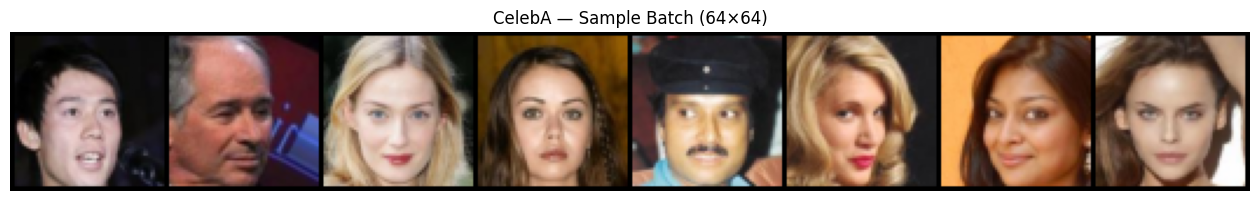

In [ ]:
# Cell 6 — Custom CelebA loader (bypasses torchvision CelebA structure issues)
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torchvision

DATA_ROOT = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba/"

# Verify images exist
all_imgs = sorted(os.listdir(DATA_ROOT))
print(f"✅ Total images found : {len(all_imgs)}")   # Expected: 202599
print(f"✅ Sample files       : {all_imgs[:5]}")

class CelebACustom(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.imgs = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0  # return 0 as dummy label

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(148),
    transforms.Resize(64),
    transforms.ToTensor(),
])

dataset = CelebACustom(DATA_ROOT, transform=transform)
loader  = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

batch_imgs, _ = next(iter(loader))
print(f"✅ Batch shape  : {batch_imgs.shape}")   # torch.Size([16, 3, 64, 64])
print(f"✅ Dataset size : {len(dataset)}")        # 202599
print(f"✅ Pixel range  : [{batch_imgs.min():.2f}, {batch_imgs.max():.2f}]")

grid = torchvision.utils.make_grid(batch_imgs[:8], nrow=8, normalize=True)
plt.figure(figsize=(16, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.title("CelebA — Sample Batch (64×64)")
plt.axis('off')
plt.show()

In [ ]:
# Run this FIRST to find exact path
import os

print(os.listdir("/kaggle/input/"))
# This will show the exact folder name of your dataset

['datasets']


In [ ]:
# Run this FIRST to find exact path
import os

print(os.listdir("/kaggle/input/datasets"))
# This will show the exact folder name of your dataset

['jessicali9530']


In [ ]:
import os

root = "/kaggle/input/datasets/jessicali9530/"
print(os.listdir(root))

['celeba-dataset']


In [ ]:
# Dig one more level
for item in os.listdir(root):
    full = os.path.join(root, item)
    if os.path.isdir(full):
        print(f"📁 {item}/ → {os.listdir(full)[:5]}")
    else:
        print(f"📄 {item}")

📁 celeba-dataset/ → ['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [ ]:
# Re-run this to overwrite dataset.py with custom loader
dataset_patch = '''import os
import torch
from PIL import Image
from typing import Optional
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from torchvision import transforms


class CelebACustom(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.imgs = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.imgs[idx])).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0


class VAEDataset(pl.LightningDataModule):

    def __init__(self, data_path, train_batch_size=64, val_batch_size=64,
                 patch_size=64, num_workers=2, pin_memory=False, **kwargs):
        super().__init__()
        # Point directly to img_align_celeba folder
        self.img_dir = os.path.join(data_path,
                       "img_align_celeba", "img_align_celeba")
        self.train_batch_size = train_batch_size
        self.val_batch_size   = val_batch_size
        self.patch_size       = patch_size
        self.num_workers      = num_workers
        self.pin_memory       = pin_memory

    def setup(self, stage: Optional[str] = None):
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.CenterCrop(148),
            transforms.Resize(self.patch_size),
            transforms.ToTensor(),
        ])
        full = CelebACustom(self.img_dir, transform=transform)
        n    = len(full)
        n_train = int(0.8 * n)
        n_val   = int(0.1 * n)
        n_test  = n - n_train - n_val
        self.train_dataset, self.val_dataset, self.test_dataset = \
            random_split(full, [n_train, n_val, n_test],
                         generator=torch.Generator().manual_seed(42))

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.train_batch_size,
                          shuffle=True,  num_workers=self.num_workers,
                          pin_memory=self.pin_memory)

    def val_dataloader(self):
        return DataLoader(self.val_dataset,   batch_size=self.val_batch_size,
                          shuffle=False, num_workers=self.num_workers,
                          pin_memory=self.pin_memory)

    def test_dataloader(self):
        return DataLoader(self.test_dataset,  batch_size=self.val_batch_size,
                          shuffle=False, num_workers=self.num_workers,
                          pin_memory=self.pin_memory)
'''

with open('/kaggle/working/PyTorch-VAE/dataset.py', 'w') as f:
    f.write(dataset_patch)

print("dataset.py patched with custom loader ✅")

dataset.py patched with custom loader ✅


In [ ]:
import sys
sys.path.insert(0, '/kaggle/working/PyTorch-VAE')

from models import VanillaVAE
import torch

model = VanillaVAE(in_channels=3, latent_dim=128)
model.eval()

x = torch.randn(1, 3, 64, 64)
with torch.no_grad():
    out = model(x)

print("✅ Input shape          :", x.shape)
print("✅ Reconstruction shape :", out[0].shape)
print("✅ Mu shape             :", out[1].shape)
print("✅ Log-var shape        :", out[2].shape)

total = sum(p.numel() for p in model.parameters())
print(f"✅ Total parameters     : {total:,}")

/kaggle/working/PyTorch-VAE/models/vanilla_vae.py:129: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/wae_mmd.py:178: SyntaxWarning: invalid escape sequence '\s'
  k(x_1, x_2) = \sum \frac{C}{C + \|x_1 - x_2 \|^2}
/kaggle/working/PyTorch-VAE/models/iwae.py:133: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/dfcvae.py:168: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/mssim_vae.py:136: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/fvae.py:156: SyntaxWarning: invalid escape seque

✅ Input shape          : torch.Size([1, 3, 64, 64])
✅ Reconstruction shape : torch.Size([1, 3, 64, 64])
✅ Mu shape             : torch.Size([1, 3, 64, 64])
✅ Log-var shape        : torch.Size([1, 128])
✅ Total parameters     : 3,937,635


In [ ]:
import os
os.chdir('/kaggle/working/PyTorch-VAE')
!python run.py --config configs/vae_kaggle.yaml


Traceback (most recent call last):
  File "/kaggle/working/PyTorch-VAE/run.py", line 32, in <module>
    data = VAEDataset(**config["data_params"], pin_memory=len(config['trainer_params'].get('gpus', [])) != 0)
                                                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: object of type 'int' has no len()


In [ ]:
# Fix run.py — replace the pin_memory line
run_patch = '''import os
import yaml
import argparse
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

from models import vae_models
from experiment import VAEXperiment
from dataset import VAEDataset

parser = argparse.ArgumentParser(description='PyTorch-VAE Runner')
parser.add_argument('--config', '-c', dest="filename", metavar='FILE',
                    help='path to config file', default='configs/vae.yaml')
args = parser.parse_args()

with open(args.filename, 'r') as f:
    config = yaml.safe_load(f)

tb_logger = TensorBoardLogger(
    save_dir=config['logging_params']['save_dir'],
    name=config['logging_params']['name']
)

model = vae_models[config['model_params']['name']](**config['model_params'])
experiment = VAEXperiment(model, config['exp_params'])

# ✅ FIX: gpus is int not list, so use bool directly
gpus = config['trainer_params'].get('gpus', 0)
pin_memory = bool(gpus)

data = VAEDataset(**config["data_params"], pin_memory=pin_memory)
data.setup()

runner = Trainer(
    logger=tb_logger,
    callbacks=[
        LearningRateMonitor(),
        ModelCheckpoint(
            save_top_k=2,
            dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
            monitor="val_loss",
            save_last=True
        ),
    ],
    **config['trainer_params']
)

print(f"======= Training {config['model_params']['name']} =======")
runner.fit(experiment, datamodule=data)
'''

with open('/kaggle/working/PyTorch-VAE/run.py', 'w') as f:
    f.write(run_patch)

print("run.py fixed ✅")

run.py fixed ✅


In [ ]:
import os
os.chdir('/kaggle/working/PyTorch-VAE')
!python run.py --config configs/vae_kaggle.yaml

Missing logger folder: /kaggle/working/logs/VanillaVAE
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
======= Training VanillaVAE =======
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type       | Params
-------------------------------------
0 | model | VanillaVAE | 3.9 M 
-------------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.751    Total estimated model params size (MB)
2026-04-15 09:02:43.262853: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to regis

In [ ]:
import yaml
with open('/kaggle/working/PyTorch-VAE/configs/vae_kaggle.yaml', 'r') as f:
    config = yaml.safe_load(f)
print("Max epochs:", config['trainer_params']['max_epochs'])

Max epochs: 15


In [ ]:
import glob, os

ckpts = glob.glob('/kaggle/working/logs/VanillaVAE/version_*/checkpoints/*.ckpt')
print("Saved checkpoints:")
for c in ckpts:
    print(c)

Saved checkpoints:
/kaggle/working/logs/VanillaVAE/version_0/checkpoints/epoch=0-step=2533.ckpt
/kaggle/working/logs/VanillaVAE/version_0/checkpoints/last.ckpt
/kaggle/working/logs/VanillaVAE/version_0/checkpoints/epoch=1-step=5066.ckpt


In [ ]:
import os
os.chdir('/kaggle/working/PyTorch-VAE')

# Find last checkpoint
import glob
ckpts = glob.glob('/kaggle/working/logs/VanillaVAE/version_*/checkpoints/last.ckpt')
print("Resuming from:", ckpts)

# Resume training
!python run.py --config configs/vae_kaggle.yaml

Resuming from: ['/kaggle/working/logs/VanillaVAE/version_0/checkpoints/last.ckpt']
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
======= Training VanillaVAE =======
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type       | Params
-------------------------------------
0 | model | VanillaVAE | 3.9 M 
-------------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.751    Total estimated model params size (MB)
2026-04-15 09:35:37.804325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT 

In [ ]:
# Reduce to 5 epochs so it finishes in ~20 mins
import yaml

with open('/kaggle/working/PyTorch-VAE/configs/vae_kaggle.yaml', 'r') as f:
    config = yaml.safe_load(f)

config['trainer_params']['max_epochs'] = 5

with open('/kaggle/working/PyTorch-VAE/configs/vae_kaggle.yaml', 'w') as f:
    yaml.dump(config, f)

print("Updated to 5 epochs ✅")

Updated to 5 epochs ✅


In [ ]:
import os
os.chdir('/kaggle/working/PyTorch-VAE')
!python run.py --config configs/vae_kaggle.yaml


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
======= Training VanillaVAE =======
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type       | Params
-------------------------------------
0 | model | VanillaVAE | 3.9 M 
-------------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.751    Total estimated model params size (MB)
2026-04-15 09:37:01.198886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been 

Checkpoints: ['/kaggle/working/logs/VanillaVAE/version_2/checkpoints/epoch=0-step=2533.ckpt', '/kaggle/working/logs/VanillaVAE/version_2/checkpoints/last.ckpt', '/kaggle/working/logs/VanillaVAE/version_2/checkpoints/epoch=1-step=5066.ckpt']
✅ Model loaded!


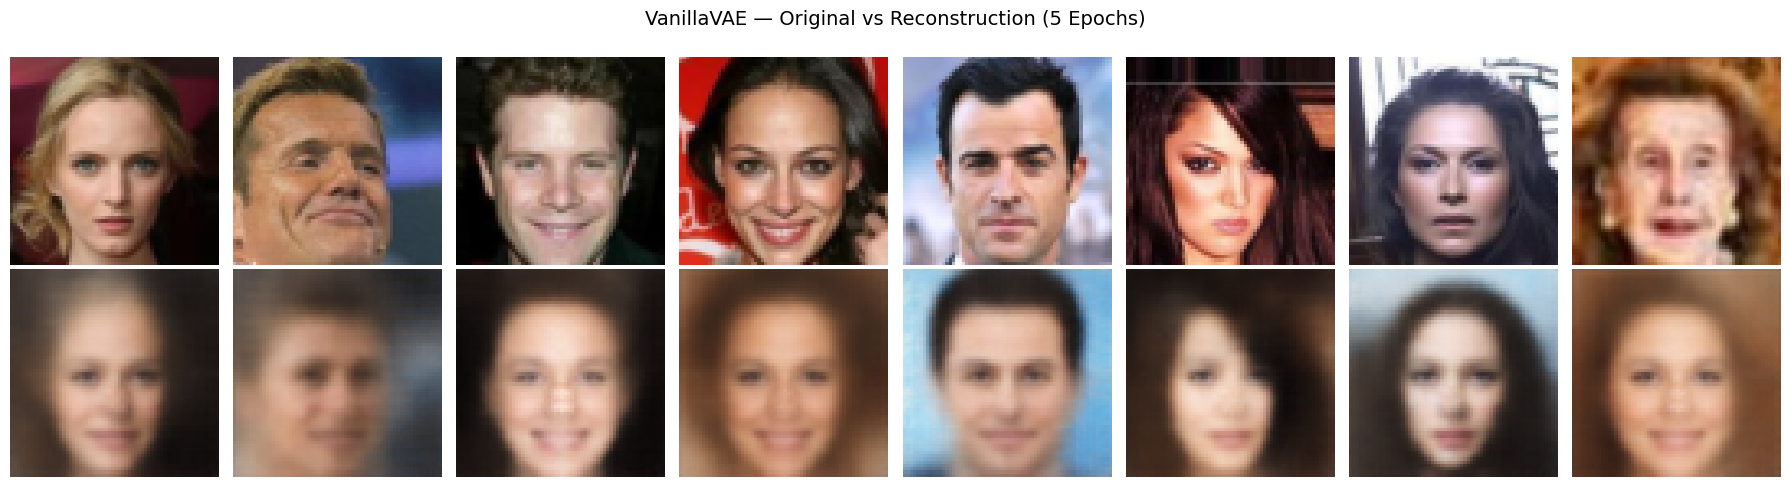

✅ Saved to /kaggle/working/reconstructions_phase1.png


In [ ]:
import torch, glob, os
import matplotlib.pyplot as plt
import torchvision
import sys
sys.path.insert(0, '/kaggle/working/PyTorch-VAE')

from models import VanillaVAE
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load checkpoint
ckpts = glob.glob('/kaggle/working/logs/VanillaVAE/version_2/checkpoints/*.ckpt')
print("Checkpoints:", ckpts)

model = VanillaVAE(in_channels=3, latent_dim=128).to(device)
ckpt = torch.load(ckpts[-1], map_location=device)
sd = {k.replace('model.', ''): v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
model.load_state_dict(sd)
model.eval()
print("✅ Model loaded!")

# Load test images
class CelebACustom(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.imgs = sorted(os.listdir(img_dir))
        self.transform = transform
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.imgs[idx])).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = transforms.Compose([
    transforms.CenterCrop(148),
    transforms.Resize(64),
    transforms.ToTensor()
])

DATA = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba/"
dataset = CelebACustom(DATA, transform=transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
imgs, _ = next(iter(loader))
imgs = imgs.to(device)

with torch.no_grad():
    recons, mu, log_var, z = model(imgs)

# Plot original vs reconstruction
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    axes[0, i].imshow(imgs[i].cpu().permute(1,2,0).clamp(0,1))
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].cpu().permute(1,2,0).clamp(0,1))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Original", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("Reconstructed", fontsize=13, fontweight='bold')
plt.suptitle("VanillaVAE — Original vs Reconstruction (5 Epochs)", fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/reconstructions_phase1.png', dpi=150)
plt.show()
print("✅ Saved to /kaggle/working/reconstructions_phase1.png")